<a href="https://colab.research.google.com/github/jmarrietar/LLMs-from-scratch-study/blob/feature%2Fstudy-session/Chapter_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Getting the GPT Model

# Basic Layers

In [1]:
import torch.nn as nn
import torch

In [6]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

In [7]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4* cfg["emb_dim"]),
            GELU(),
            nn.Linear(4*cfg["emb_dim"], cfg["emb_dim"])
        )
    def forward(self, x):
        return self.layers(x)

# MultiHeadAttention

In [4]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads

        self.head_dim = d_out // num_heads  # -> Reduces de projection dum to match desired output dim

        # Seteamos las Matrices de pesos GRANDES
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        # Una Layer Linear para combinar el output de los heads.
        self.out_proj = nn.Linear(d_out, d_out)

        # Dropout
        self.dropout = nn.Dropout(dropout)

        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
            )

    def forward(self, x):

        b, num_tokens, d_in = x.shape

        # La multiplicacion de los pesos Grandes con el Input
        # Esto nos da unas matrices (Q,K,V) grandes tambien

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # Truco: Aca implicitamente SEPARO La matriz agregandole num_heads a la dimension
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)


        # Transpose from shape(b, num_tokens, num_heads, head_dim) to (b,num_heads, num_tokens,head_dim)
        keys = keys.transpose(1,2)
        queries = queries.transpose(1,2)
        values = values.transpose(1,2)

        # Ahora: Todo como normalmente se estaba haciendo (Calcular attn scores)
        attn_scores = queries @ keys.transpose(2,3) # Dot product for each head

        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # MASK: Aplicarle mascara para hacerlo Causal Attention
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        # Attention weigth -> Apply softmax + escalamiento
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        # Aplicar Dropout
        attn_weights = self.dropout(attn_weights)

        # Obtener Vector de Contexto (Aplicarlo ahora si )
        context_vec = (attn_weights @ values).transpose(1, 2)

        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out) # combinar heads

        # optional projection

        context_vec = self.out_proj(context_vec)

        return context_vec

# TransformerBlock

In [5]:
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )

        self.ff = FeedForward(cfg)

        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])

        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):

        # Primera parte de Atention
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # add the original input back

        # Segunda parte de Feedforward
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x

# GPTModel

Analizando el codigo tengo, dentro del modelo GPP tengo:
1. Varios Bloques Transformers.
2. Layer Normalization
3. Layer Lineal.

In [8]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn. Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)

        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

In [9]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        # Transformers Block Definition # Se definen varios bloques de Transformers
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])

        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        )

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape

        # Token Embeddings
        tok_embeds = self.tok_emb(in_idx)

        # Positional Embeddings
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )

        # Sumamos los dos embedidng
        x = tok_embeds + pos_embeds

        # Aplico un Dropout
        x = self.drop_emb(x)

        # Aplico Bloques de Transformers
        x = self.trf_blocks(x)

        # Ultima capa de Normalizacion
        x = self.final_norm(x)

        logits = self.out_head(x)

        return logits

----------------------------------------

In [10]:
import torch

In [11]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

In [186]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

In [103]:
import tiktoken

#### Auxiliar functions Encode/Decode Tokens

In [14]:
def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)
    return encoded_tensor

In [15]:
def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0)
    return tokenizer.decode(flat.tolist())

In [104]:
def generate_text_simple(model, idx, max_new_tokens, context_size):

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=-1)

    return idx

In [107]:
tokenizer = tiktoken.get_encoding("gpt2")

In [108]:
start_context = "Every effort moves you"

In [109]:
token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

In [110]:
print("Output text:\n ", token_ids_to_text(token_ids, tokenizer))

Output text:
  Every effort moves you Samoa parad Defensive MacBook Referospace preparation Einstein ShepherdMot


# Generation Loss
Ejemplo de como se calculan los loss

In [111]:
# Ejemplo de palabras que ya convertimos en tokens
inputs = torch.tensor([[16833, 3626, 6100],   # ["every effort moves",
                        [40,    1107, 588]])   #  "I really like"]


In [112]:
# Y los targets de cual seria la siguiente
targets = torch.tensor([[3626, 6100, 345  ],  # ["effort moves you",
                              [1107, 588, 11311]])  #  "really like chocolate"]


**Nota:** Los targets son resultado de hacer shift del input. Y es muy importante para enseñarle al modelo como predecir el proximo token.

In [113]:
with torch.no_grad():
    logits = model(inputs)

probas = torch.softmax(logits, dim=-1)
print(probas.shape)

torch.Size([2, 3, 50257])


* El 2 corresponder a que son 2 ejemplos (2 rows) en el input ("Batch Size").
* El 3 corresponde con el numero de tokens en cada input.
* 50257 es la dimensionalidad del embedidng

In [114]:
"""
Son 2 Batches cada uno con 3 tokens
y cada token representado por un vocab de 50257
"""
logits.shape

torch.Size([2, 3, 50257])

In [115]:
probas.shape

torch.Size([2, 3, 50257])

In [116]:
"""
# Ahora para saber cual es el index con mayor valor
en cada uno de los tokens para cada uno de los batches
"""

'\n# Ahora para saber cual es el index con mayor valor \nen cada uno de los tokens para cada uno de los batches\n'

In [117]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)

In [118]:
print("Token IDs:\n", token_ids)


Token IDs:
 tensor([[[ 5873],
         [42899],
         [26729]],

        [[ 9580],
         [24016],
         [16637]]])


In [119]:
# Ahora convertirmos de tokens a texto
print(f"Targets batch 1: {token_ids_to_text(targets[0], tokenizer)}")
print(f"Outputs batch 1:"
      f" {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")


Targets batch 1:  effort moves you
Outputs batch 1:  percentage Skinner Theme


**Nota**: Estan bien disimulares por que aun no lo hemos entrenado.

Ahora, podriamos aplicarle un **loss** para saber que tan alejado de lo que queremos esta.

Entonces lo que queremos es **incrementar la probabilidad de softmax del index position correspondiente** al target correcto del Token ID.

In [120]:
text_idx = 0

In [121]:
targets[0]

tensor([3626, 6100,  345])

In [122]:
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]]

In [123]:
print("Text 1:", target_probas_1)

Text 1: tensor([4.0363e-05, 2.7361e-05, 1.1445e-05])


So what this line does is that for Tokens 3626, 6100,  345 (target) it goes to check what were the probability of choosing the correct tokens

In [124]:
text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print("Text 2:", target_probas_2)

Text 2: tensor([8.2989e-06, 9.1948e-05, 6.1120e-06])


ahh creo que ya entendi, la cosa  es que maualmente ya escogimos o sabemos cuales son los targets con targets[text_idx] de esta forma manual.

In [125]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))

In [126]:
log_probas

tensor([-10.1176, -10.5064, -11.3779, -11.6994,  -9.2943, -12.0053])

In [127]:
avg_log_probas = torch.mean(log_probas)

In [128]:
avg_log_probas

tensor(-10.8335)

In [129]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)


tensor(10.8335)


In [130]:
print("Logits shape:", logits.shape)
print("Targets shape:", targets.shape)

Logits shape: torch.Size([2, 3, 50257])
Targets shape: torch.Size([2, 3])


In [131]:
logits_flat = logits.flatten(0, 1)

In [132]:
logits.shape

torch.Size([2, 3, 50257])

In [133]:
logits

tensor([[[ 0.0321, -0.1404,  0.0355,  ...,  0.2111, -1.0006,  0.1804],
         [-0.6414, -0.3889, -0.4249,  ...,  0.5799, -1.0169, -0.6397],
         [ 1.0232, -0.8381,  0.0790,  ...,  0.6869, -0.0615,  0.1962]],

        [[-0.3740,  0.0603,  0.0761,  ..., -0.0562,  1.0225, -0.5583],
         [-0.6511,  0.1094, -0.4687,  ...,  0.0415, -0.0622,  0.0956],
         [ 0.4416,  0.7505,  1.0222,  ..., -0.7312,  1.6041, -0.3864]]])

In [134]:
logits_flat.shape

torch.Size([6, 50257])

In [135]:
logits_flat

tensor([[ 0.0321, -0.1404,  0.0355,  ...,  0.2111, -1.0006,  0.1804],
        [-0.6414, -0.3889, -0.4249,  ...,  0.5799, -1.0169, -0.6397],
        [ 1.0232, -0.8381,  0.0790,  ...,  0.6869, -0.0615,  0.1962],
        [-0.3740,  0.0603,  0.0761,  ..., -0.0562,  1.0225, -0.5583],
        [-0.6511,  0.1094, -0.4687,  ...,  0.0415, -0.0622,  0.0956],
        [ 0.4416,  0.7505,  1.0222,  ..., -0.7312,  1.6041, -0.3864]])

In [136]:
targets_flat = targets.flatten()

In [137]:
targets

tensor([[ 3626,  6100,   345],
        [ 1107,   588, 11311]])

In [138]:
targets_flat

tensor([ 3626,  6100,   345,  1107,   588, 11311])

In [139]:
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


In [140]:
targets_flat

tensor([ 3626,  6100,   345,  1107,   588, 11311])

In [141]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)

In [142]:
loss

tensor(10.8335)

# 5.1.3 Calculating the training and validation set losses

#### Descargar el texto

In [143]:
import os
import requests

if not os.path.exists("the-verdict.txt"):
    url = (
        "https://raw.githubusercontent.com/rasbt/"
        "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
        "the-verdict.txt"
    )
    file_path = "the-verdict.txt"

    response = requests.get(url, timeout=30)
    response.raise_for_status()
    with open(file_path, "wb") as f:
        f.write(response.content)

In [144]:
file_path = "the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as file:
    text_data = file.read()

#### Crear los Dataset & Dataloaders

In [145]:

from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})
        assert len(token_ids) > max_length, "Number of tokenized inputs must at least be equal to max_length+1"

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

In [146]:
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):

    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

In [147]:
train_ratio = 0.9
split_idx = int(int(train_ratio * len(text_data)))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [148]:
train_data = text_data[:split_idx]

In [149]:
GPT_CONFIG_124M["context_length"]

256

In [150]:
train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)


In [151]:
val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [152]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])


In [153]:
len(x[0])

256

In [154]:
print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)


Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


Funcion auxiliar para calcular el cross entropy loss

In [155]:
def calc_loss_batch(input_batch, target_batch, model, device):

    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)

    logits = model(input_batch) # Hace prediccion Aqui!!! Output del Modelo, los logits

    loss = torch.nn.functional.cross_entropy(logits.flatten(0,1), target_batch.flatten())

    return loss

In [156]:
# Function to compute the Training and Validation loss

def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0

    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss = total_loss + loss
        else:
            break
    return total_loss/num_batches

In [157]:
# Ahora aplicandole esto a los Loaders que tenemos
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad(): # Para no modificar weigths
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

In [158]:
train_loss

tensor(10.9905, device='cuda:0')

In [159]:
val_loss

tensor(10.9885, device='cuda:0')

# 5.2 Training an LLM

In [160]:
def evaluate_model (model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(
            train_loader, model, device, num_batches=eval_iter
        )
        val_loss = calc_loss_loader(
            val_loader, model, device, num_batches=eval_iter
        )

    model.train()
    return train_loss, val_loss


In [161]:
def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()

    context_size = model.pos_emb.weight.shape[0]

    encoded = text_to_token_ids(start_context, tokenizer).to(device)

    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model,
            idx=encoded,
            max_new_tokens=50,
            context_size=context_size
        )

    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train()


In [162]:
def train_model_simple(model, train_loader, val_loader,
                       optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):

    # Inicializamos unas variables importantes
    train_losses, val_losses, track_token_seen = [], [], []
    tokens_seen, global_step = 0, -1

    for epoch in range(num_epochs):
        model.train()
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Resets loss gradients from the previous batch
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Creo que aca se hace el backpropagation

            optimizer.step() # NO ENTIENDO MUY BIEN ESTA LINEA

            tokens_seen = tokens_seen + input_batch.numel()
            global_step = global_step + 1

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_token_seen.append(tokens_seen)

                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                    f"Train loss {train_loss:.3f}, "
                    f"Val loss {val_loss:.3f}"
                )


        generate_and_print_sample(model, tokenizer, device, start_context)

    return train_losses, val_losses, start_context


**TODO**: `Tarea` " interested readers can try to train the model on 60,000 public domain books from Project Gutenberg, where this overfitting does not occur; see appendix B for details."

In [163]:
# Lets see all in action

In [164]:
torch.manual_seed(123)

In [187]:
model = GPTModel(GPT_CONFIG_124M)
model.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [188]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004,
    weight_decay=0.1
)

In [189]:
num_epochs = 10

In [190]:
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you",
    tokenizer=tokenizer
)

Ep 1 (Step 000000): Train loss 9.933, Val loss 10.157
Ep 1 (Step 000005): Train loss 8.023, Val loss 8.344
Every effort moves you.                                                 
Ep 2 (Step 000010): Train loss 6.641, Val loss 7.054
Ep 2 (Step 000015): Train loss 6.135, Val loss 6.603
Every effort moves you, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and, and
Ep 3 (Step 000020): Train loss 5.752, Val loss 6.514
Ep 3 (Step 000025): Train loss 5.719, Val loss 6.481
Every effort moves you                                                  
Ep 4 (Step 000030): Train loss 5.633, Val loss 6.787
Ep 4 (Step 000035): Train loss 5.212, Val loss 6.481
Every effort moves you, and he was a""I to the of the of the of the his to the of the of the" of the of the of the of the his a of the his of the his, and he was a he had a of the
Ep 5 (Step 000040): Train loss 4.603, Val loss 6.469
Every effort moves you.  "I my, I was a't-. Gisb

In [184]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#model.to(device)
#1+1

2

In [193]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import torch
import numpy as np

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    # Convert lists of tensors to single tensors, then to numpy arrays
    train_losses_np = torch.stack(train_losses).cpu().numpy()
    val_losses_np = torch.stack(val_losses).cpu().numpy()

    # epochs_seen is already a torch.Tensor, convert to numpy
    epochs_seen_np = epochs_seen.cpu().numpy()

    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen_np, train_losses_np, label="Training loss")
    ax1.plot(
        epochs_seen_np, val_losses_np, linestyle="-.", label="Validation loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax2 = ax1.twiny()
    # tokens_seen is expected to be a list of numbers or a 1D numpy array
    if isinstance(tokens_seen, torch.Tensor):
        tokens_seen_np = tokens_seen.cpu().numpy()
    else:
        # Ensure tokens_seen is a numpy array for plotting
        tokens_seen_np = np.array(tokens_seen)

    ax2.plot(tokens_seen_np, train_losses_np, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()

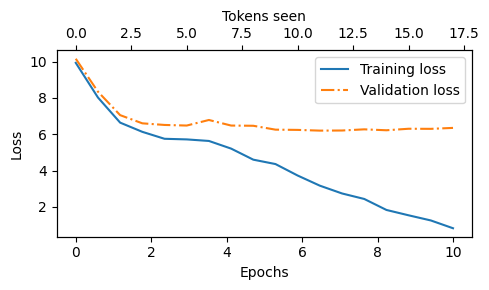

In [194]:
import numpy as np

# train_losses has 18 elements based on the previous output
num_points = len(train_losses)
epochs_tensor = torch.linspace(0, num_epochs, num_points)

# Use a numerical placeholder for tokens_seen instead of the string
# This ensures the dimensions match (18,)
tokens_seen_placeholder = np.arange(num_points)

# Now calling the function with the raw lists, as it handles conversion internally
plot_losses(epochs_tensor, tokens_seen_placeholder, train_losses, val_losses)

# 5.3 Decoding strategies to control randomness

In [173]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

In [222]:
def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):

    # The for loop is the same as before:
    # gets logits and only focuses on the last time step.

    for _ in range(max_new_tokens): # Foor loop para generar tantos nuevos tokens como nos lo piden
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # FILTER logits with top_k sampling
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits < min_val,
                torch.tensor(float('-inf')).to(logits.device),
                logits
            )

        # APPLIES TEMPERATURE SCALING
        if temperature > 0.0:
            logits = logits / temperature #APPLY TEMPERATURE TO LOGITS
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        # Stop generating early if end-od-sequence token is encountered.
        if idx_next == eos_id:
            break

        idx = torch.cat((idx, idx_next), dim=1)

    return idx


# 5.4  Loading and saving model weights in PyTorch

In [195]:
torch.save(model.state_dict(), "model.pth")

In [196]:
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(torch.load("model.pth", map_location=device))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [197]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    },
    "model_and_optimizer.pth"
)

In [198]:
checkpoint = torch.load("model_and_optimizer.pth", map_location=device)
model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
model.train();

# 5.5 Loading pretrained weights from OpenAI

In [199]:
!pip install tensorflow>=2.15.0  tqdm>=4.66

Para descargar los pesos

In [200]:
import urllib.request
url = (
    "https://raw.githubusercontent.com/rasbt/"
    "LLMs-from-scratch/main/ch05/"
    "01_main-chapter-code/gpt_download.py"
)
filename = url.split('/')[-1]
urllib.request.urlretrieve(url, filename)

('gpt_download.py', <http.client.HTTPMessage at 0x7a7620fcc7a0>)

In [202]:
from gpt_download import download_and_load_gpt2

settings, params = download_and_load_gpt2(
    model_size="124M", models_dir="gpt2"
)

checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 260kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 3.11MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 255kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [00:42<00:00, 11.8MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 10.3MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 1.63MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.60MiB/s]


In [203]:
print("Settings:", settings)
print("Parameter dictionary keys:", params.keys())


Settings: {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}
Parameter dictionary keys: dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [204]:
print(params["wte"])
print("Token embedding weight tensor dimensions:", params["wte"].shape)


[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
Token embedding weight tensor dimensions: (50257, 768)


Funcion Para saber si lo que estamos cargando si es lo adecuado o no:

In [205]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, "
                          "Right: {right.shape}"
        )
    return torch.nn.Parameter(torch.tensor(right))

In [206]:
import numpy as np

Se tiene otra funcion para cargar los pesos a cada una de los bloques. (El autor dice que fue mucho guesswork, tanteo, porque se llaman de forma distinta los pesos).

In [208]:
def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)
        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)
        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)

        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])
        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])
        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

In [209]:
model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

In [210]:
model_name = "gpt2-small (124M)"
NEW_CONFIG = GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])

Careful readers may remember that we used a 256-token length earlier, but the original GPT-2 models from OpenAI were trained with a 1,024-token length, so we have to update the NEW_CONFIG accordingly:

In [211]:
NEW_CONFIG.update({"context_length": 1024})

OpenAI used bias vectors in the multi-head attention module’s linear layers to implement the query, key, and value matrix computations. Bias vectors are not com- monly used in LLMs anymore as they don’t improve the modeling performance and are thus unnecessary. However, since we are working with pretrained weights, we need to match the settings for consistency and enable these bias vectors:

In [212]:
NEW_CONFIG.update({"qkv_bias": True})

In [213]:
gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [214]:
load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [215]:
torch.manual_seed(123)

In [257]:
token_ids = generate(
model=gpt,
idx=text_to_token_ids("Every effort moves you", tokenizer).to(device), max_new_tokens=25,
context_size=NEW_CONFIG["context_length"],
top_k=50,
temperature=0.1
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you forward, but you have to keep moving forward.

"I'm not going to say that I'm going to say
